<a href="https://colab.research.google.com/github/isabellimavallejo-tech/Projeto-Machine-Learning/blob/main/Projeto_Final_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final Machine Learning

In [2]:
# Import: bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import: Datasets

from sklearn.datasets import load_wine
from sklearn.tree import plot_tree
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from joblib.numpy_pickle import load
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
from sklearn.metrics import (ConfusionMatrixDisplay)

# Carregando o dataset
wine = load_wine(as_frame=True)

# Transformando o Dataset em Dataframe
df = pd.DataFrame(wine.data, columns = wine.feature_names)
df["target"] = wine.target
df.head()

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

### Inspeção Inicial

In [6]:
# Dimensões
print("Dimensões:", df.shape)

# Tipos
print("\nTipos:")
display(df.dtypes)

# Valores Ausentes
print("\nValores ausentes:")
display(df.isna().sum())

# Duplicatas
print("\nDuplicatas:", df.duplicated().sum())

# Estatística
print("\nEstatísticas:")
display(df.describe())

Dimensões: (178, 14)

Tipos:


,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64



Valores ausentes:


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Duplicatas: 0

Estatísticas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Análise de Classes

Quantidade de Classes: ['class_0' 'class_1' 'class_2']


,count
target,
0,59
1,71
2,48


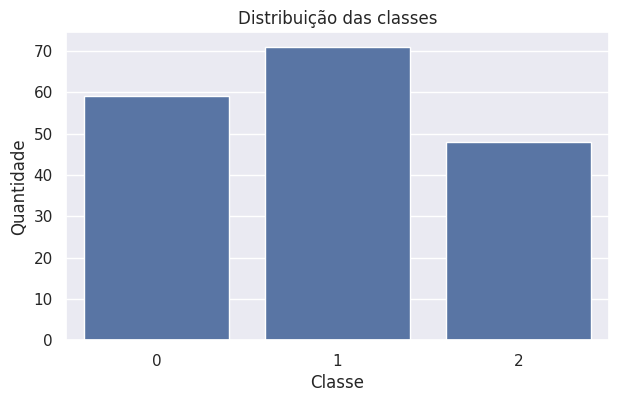

In [8]:
print("Quantidade de Classes:", wine.target_names)
display(df["target"].value_counts().sort_index())

# Plotar gráfico
plt.figure(figsize=(7, 4))
sns.countplot(data=df,
              x="target")
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

### Separando features e target

In [16]:
# Inserindo variáveis

X = df.drop('target', axis=1)     # Características químicas

y = df['target']     # Classes

# Treinar o dataset

treinar = ("X,y")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print( "Treino e teste:", X_train.shape,",", X_test.shape)

Treino e teste: (142, 13) , (36, 13)


### Aplicando modelo: PCA

Variancia por cada componente: 
[9.98091230e-01 1.73591562e-03 9.49589576e-05 5.02173562e-05
 1.23636847e-05 8.46213034e-06 2.80681456e-06 1.52308053e-06
 1.12783044e-06 7.21415811e-07 3.78060267e-07 2.12013755e-07
 8.25392788e-08]
Número original de dimensões: 13
Número de dimensões após o PCA: 13
Variância total preservada:
1.0


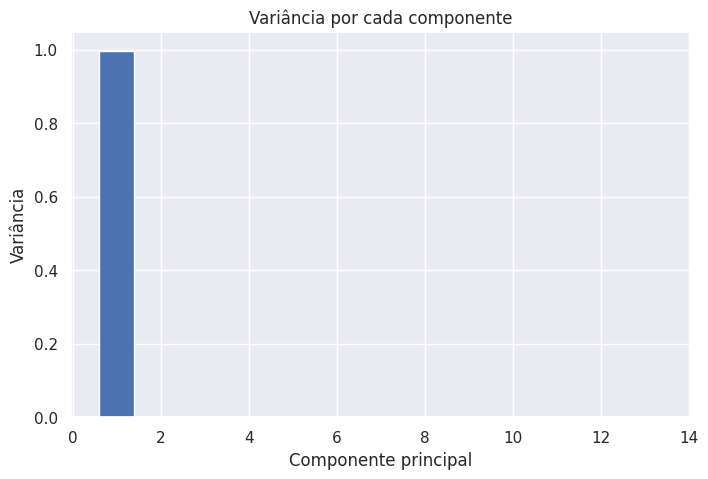

In [41]:
X = df.drop('target', axis=1)

from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X)
print("Variancia por cada componente: ")
print(pca.explained_variance_ratio_)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(
    range(1,len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
    )

plt.xlabel("Componente principal")
plt.ylabel("Variância")
plt.title("Variância por cada componente")

X_reduzido = pca.transform(X)

print("Número original de dimensões:", X.shape[1])
print("Número de dimensões após o PCA:", X_reduzido.shape[1])

print("Variância total preservada:")
print(np.sum(pca.explained_variance_ratio_))

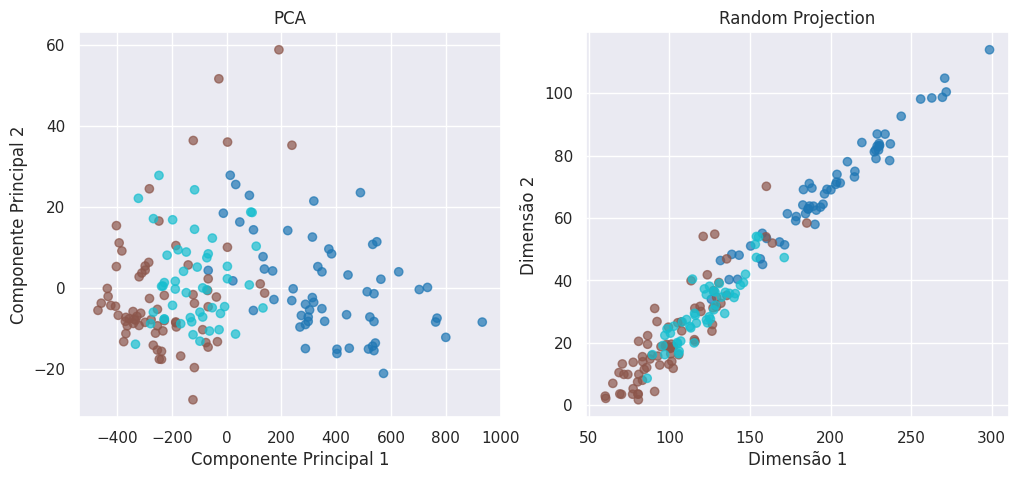

Número de dimensões após Projeção Aleatória de Gauss:  (178, 2)


In [30]:
import matplotlib.pyplot as plt
from sklearn.random_projection import GaussianRandomProjection

# Criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCA

scatter = axes[0].scatter(
    X_reduzido[:,0],
    X_reduzido[:,1],
    c=y,
    cmap="tab10",
    alpha=0.7
)

axes[0].set_title("PCA")
axes[0].set_xlabel("Componente Principal 1")
axes[0].set_ylabel("Componente Principal 2")

# Random Projects
# Aplicar Projeção Aleatória
grp = GaussianRandomProjection(n_components=2, random_state=42)
X_rp = grp.fit_transform(X)

scatter = axes[1].scatter(
    X_rp[:,0],
    X_rp[:,1],
    c=y,
    cmap="tab10",
    alpha=0.7
)

axes[1].set_title("Random Projection")
axes[1].set_xlabel("Dimensão 1")
axes[1].set_ylabel("Dimensão 2")

plt.show()

print("Número de dimensões após Projeção Aleatória de Gauss: ", X_rp.shape)

### Métricas

In [34]:
# Acurácia

# Treinar um modelo de classificação (ex: Decision Tree Classifier)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

A = accuracy_score(y_test, y_pred)
print("Acurácia:", A)

# Matriz Confusão
mc = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(mc)

Acurácia: 0.9444444444444444

Matriz de Confusão:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


### Investigar overfitting

In [38]:
resultados = [] # lista

for profundidade in range(1, 11):
    arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )
    arvore.fit(X_train, y_train)

    resultados.append({
        "max_depth": profundidade,
        "accuracy_treino": arvore.score(X_train, y_train),
        "accuracy_teste": arvore.score(X_test, y_test)
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df)

,max_depth,accuracy_treino,accuracy_teste
0,1,0.661972,0.583333
1,2,0.936620,0.861111
2,3,0.992958,0.944444
3,4,1.000000,0.944444
4,5,1.000000,0.944444
5,6,1.000000,0.944444
6,7,1.000000,0.944444
7,8,1.000000,0.944444
8,9,1.000000,0.944444
9,10,1.000000,0.944444


O overfitting acontece a partir de max_depth = 4.
O modelo ainda está aprendendo com o treino mesmo que a acurácia esteja 100%

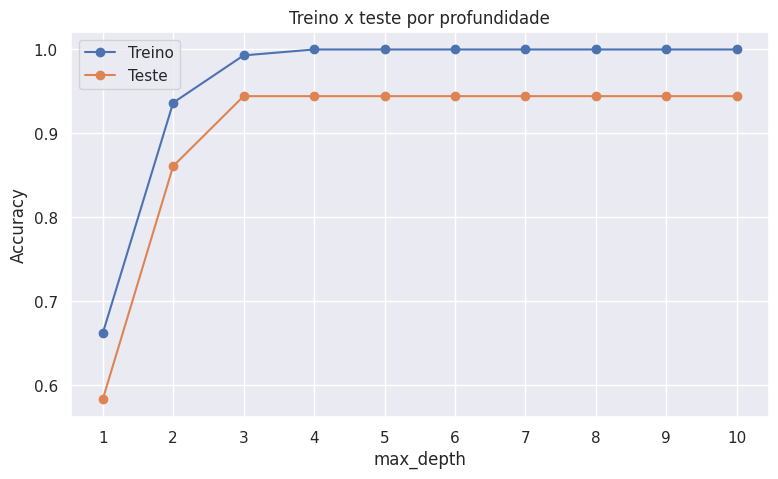

In [39]:
plt.figure(figsize=(9, 5))
plt.plot(
    resultados_df["max_depth"],
    resultados_df["accuracy_treino"],
    marker="o",
    label="Treino"
)
plt.plot(
    resultados_df["max_depth"],
    resultados_df["accuracy_teste"],
    marker="o",
    label="Teste"
)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Treino x teste por profundidade")
plt.xticks(range(1, 11))
plt.legend()
plt.show()
